# Piecewise inequalities — the `sign` parameter

`add_piecewise_formulation` accepts a ``sign`` parameter to express one-sided
bounds of the form `y ≤ f(x)` or `y ≥ f(x)`:

```python
m.add_piecewise_formulation(
    (fuel,  y_pts),   # output — gets the sign
    (power, x_pts),   # input — always equality
    sign="<=",
)
```

This notebook walks through the math, the **first-tuple convention**, and
the feasible regions produced by each method (LP, SOS2, incremental).

## Key points

| | Behaviour |
|---|---|
| `sign="=="` (default) | All expressions lie exactly on the curve. |
| `sign="<="` | First expression is bounded above by `f(rest)`. |
| `sign=">="` | First expression is bounded below by `f(rest)`. |

**First-tuple convention**: only the *first* tuple's variable gets the sign.
All remaining tuples are equality (inputs on the curve).  This restriction
keeps the semantics unambiguous — it's always "output sign function(inputs)".

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import linopy

## Setup — a concave curve

We use a concave, monotonically increasing curve.  With `sign="<="`, the LP
method is applicable (concave + `<=` is a tight relaxation).

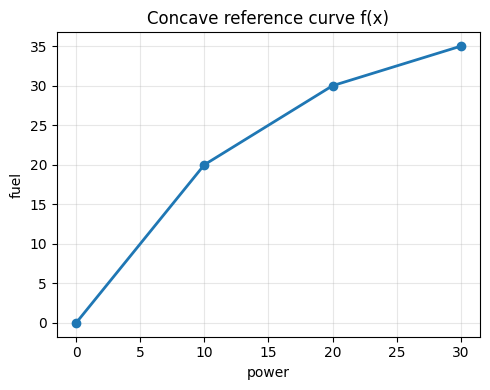

In [2]:
x_pts = np.array([0.0, 10.0, 20.0, 30.0])
y_pts = np.array([0.0, 20.0, 30.0, 35.0])  # slopes 2, 1, 0.5 (concave)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x_pts, y_pts, "o-", color="C0", lw=2)
ax.set(xlabel="power", ylabel="fuel", title="Concave reference curve f(x)")
ax.grid(alpha=0.3)
plt.tight_layout()

## Three methods, identical feasible region

With `sign="<="` and our concave curve, the three methods give the **same**
feasible region within `[x_0, x_n]`:

- **`method="lp"`** — tangent lines + domain bounds.  No auxiliary variables.
- **`method="sos2"`** — lambdas + SOS2 + split link (input equality, output
  signed).  Solver picks the segment.
- **`method="incremental"`** — delta fractions + binaries + split link.
  Same mathematics, MIP encoding instead of SOS2.

`method="auto"` dispatches to `"lp"` whenever applicable — it's always
preferable because it's pure LP.

Let's verify they produce the same solution at `power=15`.

In [3]:
def solve(method, power_val):
    m = linopy.Model()
    power = m.add_variables(lower=0, upper=30, name="power")
    fuel = m.add_variables(lower=0, upper=40, name="fuel")
    m.add_piecewise_formulation(
        (fuel, y_pts),      # output, signed
        (power, x_pts),     # input, ==
        sign="<=",
        method=method,
    )
    m.add_constraints(power == power_val)
    m.add_objective(-fuel)  # maximise fuel to push against the bound
    m.solve()
    return float(m.solution["fuel"]), list(m.variables), list(m.constraints)


for method in ["lp", "sos2", "incremental"]:
    fuel_val, vars_, cons_ = solve(method, 15)
    print(f"{method:12}: fuel={fuel_val:.2f}  vars={vars_}  cons={cons_}")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-12-18
Read LP format model from file /private/var/folders/7j/18_93__x4wl2px44pq3f570m0000gn/T/linopy-problem-q1eplgyx.lp
Reading time = 0.00 seconds
obj: 6 rows, 2 columns, 9 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 6 rows, 2 columns and 9 nonzeros (Min)
Model fingerprint: 0x5f732d5f
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [5e-01, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [3e+01, 4e+01]
  RHS range        [1e+01, 3e+01]

Presolve removed 6 rows and 2 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.5000000e+01   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0

Dual values of MILP couldn't be parsed


sos2        : fuel=25.00  vars=['power', 'fuel', 'pwl0_lambda']  cons=['pwl0_convex', 'pwl0_link', 'pwl0_output_link', 'con0']
Set parameter Username
Academic license - for non-commercial use only - expires 2026-12-18
Read LP format model from file /private/var/folders/7j/18_93__x4wl2px44pq3f570m0000gn/T/linopy-problem-ul8o72b1.lp
Reading time = 0.00 seconds
obj: 10 rows, 8 columns, 23 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 10 rows, 8 columns and 23 nonzeros (Min)
Model fingerprint: 0xa97916e1
Model has 1 linear objective coefficients
Variable types: 5 continuous, 3 integer (3 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 4e+01]
  RHS range        [2e+01, 2e+01]

Presolve removed 10 rows and 8 columns
Presolve time: 0.00s
Presolve: All

Dual values of MILP couldn't be parsed


incremental : fuel=25.00  vars=['power', 'fuel', 'pwl0_delta', 'pwl0_order_binary']  cons=['pwl0_delta_bound', 'pwl0_fill_order', 'pwl0_binary_order', 'pwl0_link', 'pwl0_output_link', 'con0']


All three give `fuel=25` at `power=15` (which is `f(15)` exactly) — the math
is equivalent.  The LP method is strictly cheaper: no auxiliary variables,
just three chord constraints and two domain bounds.

The SOS2 and incremental methods create lambdas (or deltas + binaries) and
split the link into an input-equality constraint plus a signed output link —
but the feasible region is the same.

## Visualising the feasible region

The feasible region for `(power, fuel)` with `sign="<="` is the **hypograph**
of `f` restricted to the curve's x-domain:

$$\{ (x, y) : x_0 \le x \le x_n,\ y \le f(x) \}$$

We colour green feasible points, red infeasible ones.  Three test points:

- `(15, 15)` — inside the curve, `15 ≤ f(15)=25` ✓
- `(15, 25)` — on the curve ✓
- `(15, 29)` — above `f(15)`, should be infeasible ✗
- `(35, 20)` — power beyond domain, infeasible ✗

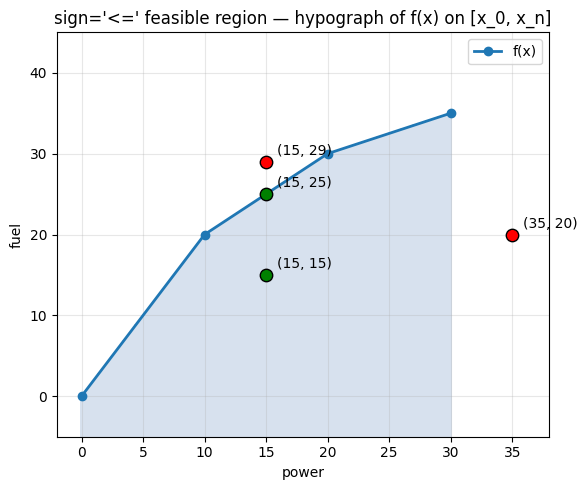

In [4]:
def in_hypograph(px, py):
    if px < x_pts[0] or px > x_pts[-1]:
        return False
    return py <= np.interp(px, x_pts, y_pts)


xx, yy = np.meshgrid(np.linspace(-2, 38, 200), np.linspace(-5, 45, 200))
region = np.vectorize(in_hypograph)(xx, yy)

test_points = [(15, 15), (15, 25), (15, 29), (35, 20)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, region, levels=[0.5, 1],
            colors=["lightsteelblue"], alpha=0.5)
ax.plot(x_pts, y_pts, "o-", color="C0", lw=2, label="f(x)")
for px, py in test_points:
    feas = in_hypograph(px, py)
    ax.scatter([px], [py],
               color="green" if feas else "red",
               zorder=5, s=80, edgecolors="black")
    ax.annotate(f"({px}, {py})", (px, py), textcoords="offset points",
                xytext=(8, 5))
ax.set(xlabel="power", ylabel="fuel",
       title="sign='<=' feasible region — hypograph of f(x) on [x_0, x_n]")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

## The first-tuple convention

Why does only *one* variable get the sign?  Because the math of
"bound one output by a function of the others" has a single inequality
direction.  For 3+ variables:

```python
m.add_piecewise_formulation(
    (fuel,  y_pts),     # output — sign
    (power, x_pts),     # input — ==
    (heat,  z_pts),     # input — ==
    sign="<=",
)
```

reads as `fuel ≤ g(power, heat)` on the joint curve.  All inputs must lie on
the curve (equality); only the output is bounded.

Allowing arbitrary per-variable signs would open up cases like
"`fuel ≤ f(power)` AND `heat ≤ f(power)`" which is a dominated region, not a
hypograph — mathematically valid but rarely what users want.  Restricting to
one output keeps the semantics unambiguous.

## When LP is not applicable

For **non-convex / non-concave** curves, tangent lines give only the convex
envelope — a **relaxation**, not the exact hypograph.  `method="auto"`
detects this and falls back to SOS2 (or incremental for monotonic
breakpoints), which encodes the exact hypograph via discrete segment
selection.

For **3+ variables** with inequality, LP is not applicable at all:
tangent *lines* can only express *one input → one output*.  With multiple
inputs on a 1-D curve in N-D space, identifying which segment we're on
requires SOS2/binary.  Auto dispatches to SOS2 here.

Explicit `method="lp"` with an incompatible curve or N > 2 raises an error
with a clear message.

In [5]:
# Non-convex curve — auto falls back to SOS2
x_nc = [0, 10, 20, 30]
y_nc = [0, 20, 10, 30]  # not monotonic in slope

m = linopy.Model()
x = m.add_variables(lower=0, upper=30, name="x")
y = m.add_variables(lower=0, upper=40, name="y")
f = m.add_piecewise_formulation(
    (y, y_nc),
    (x, x_nc),
    sign="<=",
)
print(f"auto picked: {f.method}")

# Explicit lp on non-concave raises
try:
    m2 = linopy.Model()
    x2 = m2.add_variables(lower=0, upper=30, name="x")
    y2 = m2.add_variables(lower=0, upper=40, name="y")
    m2.add_piecewise_formulation(
        (y2, y_nc), (x2, x_nc), sign="<=", method="lp"
    )
except ValueError as e:
    print(f"lp error: {e}")

auto picked: sos2
lp error: method='lp' with sign='<=' requires a concave or linear curve, got 'mixed'.


## Summary

- Use `sign="="` (default) for exact equality on the curve.
- Use `sign="<="` / `sign=">="` for one-sided bounds on the first tuple's
  expression.
- `method="auto"` picks the most efficient formulation: LP for convex/concave
  2-variable inequalities, otherwise SOS2 or incremental.
- Only the *first* tuple gets the sign — all other tuples are always
  equality.  This restriction keeps semantics unambiguous.